In [1]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
import numpy as np
df["Sex"]=np.where(df["Sex"]=="male",1,0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Alternate method.
# df["Sex"]=df["Sex"].map({"female":0,"male":1})
# df.head()

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
x=df[["Pclass","Sex","Age","SibSp","Parch","Fare"]]
y=df["Survived"]
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [10]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion="entropy",n_estimators=100,random_state=1)
model=rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [11]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print()
print("Accuracy Score:",accuracy_score(y_test,y_pred))

[[96 10]
 [28 45]]

Accuracy Score: 0.7877094972067039


In [12]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

96 10 28 45


In [13]:
print("Accuracy Score :",(TP+TN)/(TP+TN+FP+FN))

Accuracy Score : 0.7877094972067039


In [14]:
print("Error Rate :",(FP+FN)/(TP+TN+FP+FN))

Error Rate : 0.2122905027932961


In [15]:
print("Sensitivity :",(TP)/(TP+FN))

Sensitivity : 0.6164383561643836


In [16]:
print("Specificity :",(TN)/(TN+FP))

Specificity : 0.9056603773584906


In [17]:
print("Precision Score :",(TP)/(TP+FP))

Precision Score : 0.8181818181818182


In [18]:
sample=x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(prediction)

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292
[1]


In [19]:
sample_dict=sample.iloc[0].to_dict()
print(f"Sample Passenger: {sample_dict}")
print(f"Predicted Survival: {"Survived" if prediction[0]==1 else "Not Survived"}")

Sample Passenger: {'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
Predicted Survival: Survived


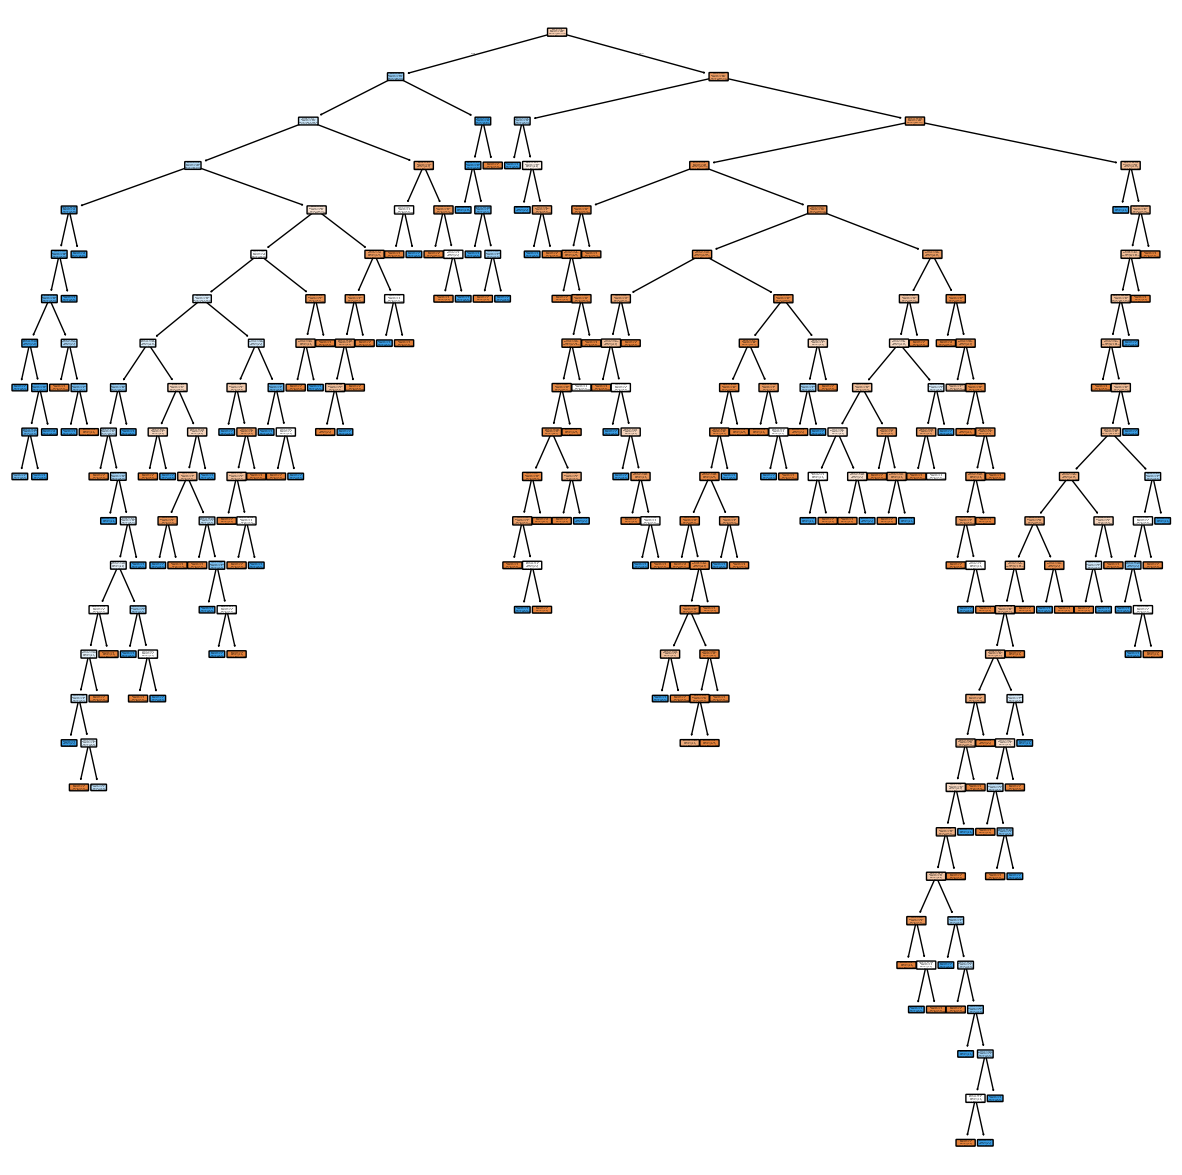

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[0]
plt.figure(figsize=(15,15))
plot_tree(choose_tree,
         feature_names=["Pclass","Sex","Age","SibSp","Parch","Fare"],
          class_names=["Not Survived","Survived"],
          filled=True,rounded=True)
plt.show()

In [21]:
import pandas as pd
data={"Weight":[150,170,140,180,160,155],
      "Texture":["Smooth","Rough","Smooth","Rough","Smooth","Rough"],
      "Color":["Red","Orange","Green","Orange","Red","Yellow"],
      "Fruits":["Apple","Orange","Apple","Orange","Apple","Orange"]}
df=pd.DataFrame(data)
df

,Weight,Texture,Color,Fruits
0,150,Smooth,Red,Apple
1,170,Rough,Orange,Orange
2,140,Smooth,Green,Apple
3,180,Rough,Orange,Orange
4,160,Smooth,Red,Apple
5,155,Rough,Yellow,Orange


In [22]:
import numpy as np
df["Texture"]=np.where(df["Texture"]=="Smooth",0,1)
df

,Weight,Texture,Color,Fruits
0,150,0,Red,Apple
1,170,1,Orange,Orange
2,140,0,Green,Apple
3,180,1,Orange,Orange
4,160,0,Red,Apple
5,155,1,Yellow,Orange


In [23]:
import numpy as np
df["Color"]=np.where(df["Color"]=="Red",0,
            np.where(df["Color"]=="Orange",1,
            np.where(df["Color"]=="Green",2,3)))
df
# multiple times run nhi karvanu baki else ni value badhi jagya aavi jase.

,Weight,Texture,Color,Fruits
0,150,0,0,Apple
1,170,1,1,Orange
2,140,0,2,Apple
3,180,1,1,Orange
4,160,0,0,Apple
5,155,1,3,Orange


In [24]:
x=df[["Weight","Texture","Color"]]
y=df["Fruits"]
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4, 3)
(2, 3)
(4,)
(2,)


In [26]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion="entropy",n_estimators=100,random_state=1)
model=rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

['Apple' 'Orange']


In [27]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print()
print("Accuracy Score:",accuracy_score(y_test,y_pred))

[[1 0]
 [0 1]]

Accuracy Score: 1.0


In [28]:
sample=x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(prediction)

   Weight  Texture  Color
2     140        0      2
['Apple']


In [29]:
sample_dict=sample.iloc[0].to_dict()
print(f"Sample Passenger: {sample_dict}")
print(f"Predicted Survival: {"Survived" if prediction[0]==1 else "Not Survived"}")

Sample Passenger: {'Weight': 140, 'Texture': 0, 'Color': 2}
Predicted Survival: Not Survived


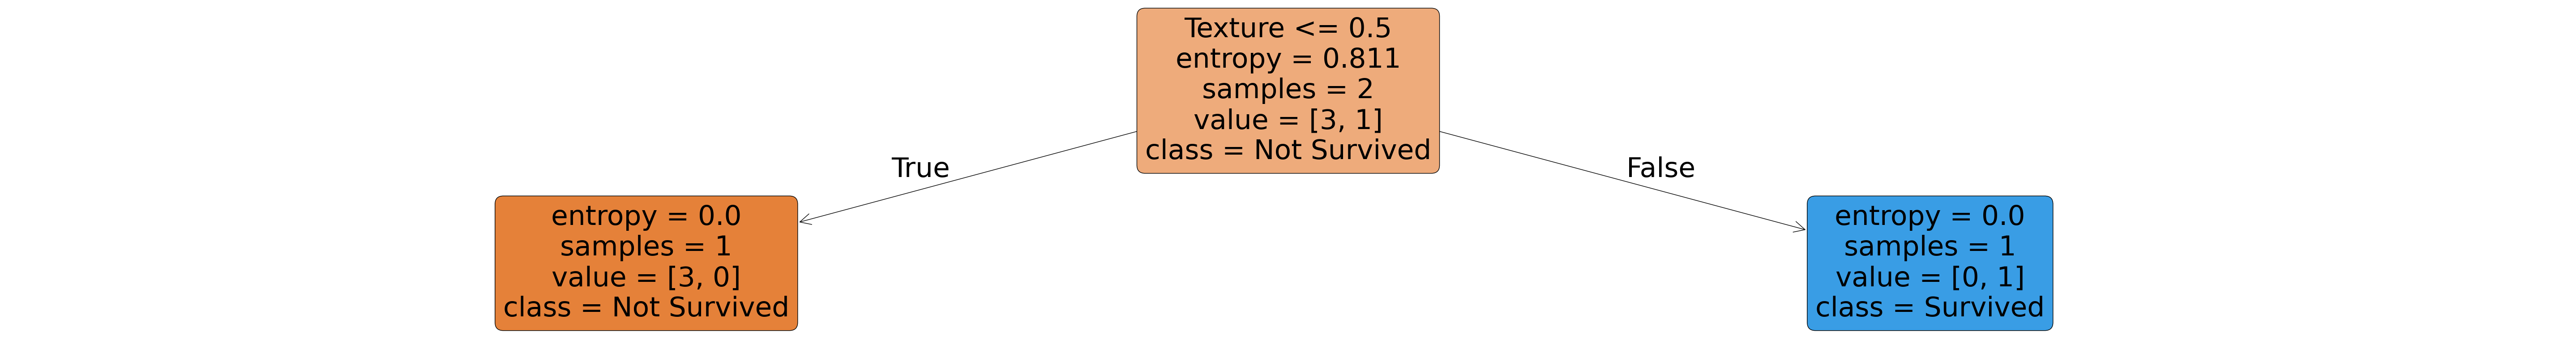

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[0]
plt.figure(figsize=(74,10))
plot_tree(choose_tree,
         feature_names=["Weight","Texture","Color"],
          class_names=["Not Survived","Survived"],
          filled=True,rounded=True)
plt.show()

In [31]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
x=df.iloc[:,0:8]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [33]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [35]:
from sklearn.svm import SVC
classifier=SVC(kernel="rbf",C=1.0,random_state=0)
model=classifier.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


In [36]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,prediction)
print(cm)
print("Accuracy Score:",accuracy_score(y_test,prediction))

[[93  6]
 [27 28]]
Accuracy Score: 0.7857142857142857
